# Causal Drift Scheduling Analysis (2007→2018 and 2018→2007)

This notebook computes:
- Post-shift miss AUC (reverse direction included)
- Paper-ready tables (both directions)
- ΔHR with 95% CI per cache size (block bootstrap)

Outputs:
- Tables: `results/tables/causal_hr_table.(csv|tex)` and `results/tables/causal_auc_table.(csv|tex)`
- Figures: `results/figures/causal_delta_hr_*.{png,pdf}` and `results/figures/causal_postshift_auc_*.{png,pdf}`


In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility for bootstrap
RNG_SEED = 7

# Experiment constants (match causal runs)
SEG_A = 5_000_000
WARMUP = 1_000_000
WINDOW_POST = 30  # slots after change-point
BLOCK_LEN = 5
N_BOOT = 2000

# Resolve project root (works whether notebook runs from repo root or /notebooks)
PROJECT_ROOT = Path.cwd().resolve()
for _ in range(4):
    if (PROJECT_ROOT / 'results').exists() and (PROJECT_ROOT / 'src').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

# Result roots
ROOT_2007_TO_2018 = PROJECT_ROOT / 'results/causal_wikipedia_september_2007_to_wiki2018'
ROOT_2018_TO_2007 = PROJECT_ROOT / 'results/causal_wiki2018_to_wikipedia_september_2007'

# Output dirs
FIG_DIR = PROJECT_ROOT / 'results/figures'
TAB_DIR = PROJECT_ROOT / 'results/tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})



In [2]:
def list_sizes(root: Path):
    sizes = set()
    for p in root.glob('001_summary_ilnse_A2_drift_causal_*_*.json'):
        try:
            size = int(p.stem.split('_')[-1])
            sizes.add(size)
        except Exception:
            pass
    return sorted(sizes)


def load_summary(root: Path, variant: str, size: int):
    path = root / f'001_summary_ilnse_A2_drift_causal_{variant}_{size}.json'
    with path.open() as f:
        return json.load(f)


def load_slot_hr(root: Path, variant: str, size: int):
    path = root / f'001_ilnse_A2_drift_causal_{variant}_{size}.jsonl'
    hrs = []
    with path.open() as f:
        for line in f:
            row = json.loads(line)
            if row.get('phase') != 'cache':
                continue
            hrs.append(float(row['slot_hit_ratio']))
    return np.array(hrs, dtype=float)


def block_bootstrap_mean_diff(a, b, block_len=BLOCK_LEN, n_boot=N_BOOT, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    n = min(len(a), len(b))
    if n == 0:
        return float('nan'), float('nan'), float('nan')
    a = a[:n]
    b = b[:n]
    diff = a - b
    mean = float(np.mean(diff))
    max_start = max(0, n - block_len)
    starts = np.arange(max_start + 1)
    n_blocks = int(np.ceil(n / block_len))
    boots = []
    for _ in range(n_boot):
        idx = rng.choice(starts, size=n_blocks, replace=True)
        blocks = []
        for s in idx:
            blocks.append(np.arange(s, min(s + block_len, n)))
        samp = np.concatenate(blocks)[:n]
        boots.append(float(np.mean(diff[samp])))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return mean, float(lo), float(hi)


def post_shift_miss_window(hrs, slot_size, seg_a=SEG_A, warmup=WARMUP, window_post=WINDOW_POST):
    change_slot = seg_a // slot_size
    warmup_slots = warmup // slot_size
    shift_idx = max(0, change_slot - warmup_slots - 1)
    post = hrs[shift_idx:shift_idx + window_post]
    if len(post) == 0:
        return np.array([], dtype=float)
    return 1.0 - post


def post_shift_miss_auc(hrs, slot_size, seg_a=SEG_A, warmup=WARMUP, window_post=WINDOW_POST):
    miss = post_shift_miss_window(hrs, slot_size, seg_a, warmup, window_post)
    if len(miss) == 0:
        return float('nan')
    return float(np.sum(miss))



In [3]:
def build_tables(root: Path, label: str):
    sizes = list_sizes(root)
    rows = []
    auc_rows = []

    for size in sizes:
        s_ad = load_summary(root, 'adaptive', size)
        s_fx = load_summary(root, 'fixed_iso', size)
        s_pm = load_summary(root, 'permuted_iso', size)

        hr_ad = s_ad['hit_ratio']
        hr_fx = s_fx['hit_ratio']
        hr_pm = s_pm['hit_ratio']

        # CI for delta HR (slot-level)
        hr_ad_slots = load_slot_hr(root, 'adaptive', size)
        hr_fx_slots = load_slot_hr(root, 'fixed_iso', size)
        hr_pm_slots = load_slot_hr(root, 'permuted_iso', size)

        d_af, lo_af, hi_af = block_bootstrap_mean_diff(hr_ad_slots, hr_fx_slots)
        d_ap, lo_ap, hi_ap = block_bootstrap_mean_diff(hr_ad_slots, hr_pm_slots)

        rows.append({
            'direction': label,
            'cache_size': size,
            'hr_adaptive': hr_ad,
            'hr_fixed': hr_fx,
            'hr_permuted': hr_pm,
            'delta_adapt_fixed': d_af,
            'ci_af_lo': lo_af,
            'ci_af_hi': hi_af,
            'delta_adapt_perm': d_ap,
            'ci_ap_lo': lo_ap,
            'ci_ap_hi': hi_ap,
            'admit_budget_total_adaptive': s_ad.get('admit_budget_total'),
            'admit_budget_total_fixed': s_fx.get('admit_budget_total'),
            'admit_budget_total_perm': s_pm.get('admit_budget_total'),
        })

        # Post-shift miss AUC and CI for delta AUC
        slot_size = s_ad['slot_size']
        miss_ad = post_shift_miss_window(hr_ad_slots, slot_size)
        miss_fx = post_shift_miss_window(hr_fx_slots, slot_size)
        miss_pm = post_shift_miss_window(hr_pm_slots, slot_size)
        n = min(len(miss_ad), len(miss_fx), len(miss_pm))
        miss_ad = miss_ad[:n]
        miss_fx = miss_fx[:n]
        miss_pm = miss_pm[:n]

        auc_ad = float(np.sum(miss_ad)) if n else float('nan')
        auc_fx = float(np.sum(miss_fx)) if n else float('nan')
        auc_pm = float(np.sum(miss_pm)) if n else float('nan')

        d_auc_af, lo_auc_af, hi_auc_af = block_bootstrap_mean_diff(miss_ad, miss_fx)
        d_auc_ap, lo_auc_ap, hi_auc_ap = block_bootstrap_mean_diff(miss_ad, miss_pm)
        # Convert per-slot mean diff to AUC (sum) diff
        d_auc_af *= n
        lo_auc_af *= n
        hi_auc_af *= n
        d_auc_ap *= n
        lo_auc_ap *= n
        hi_auc_ap *= n

        auc_rows.append({
            'direction': label,
            'cache_size': size,
            'miss_auc_adaptive': auc_ad,
            'miss_auc_fixed': auc_fx,
            'miss_auc_permuted': auc_pm,
            'delta_auc_adapt_fixed': d_auc_af,
            'delta_auc_adapt_perm': d_auc_ap,
            'ci_auc_af_lo': lo_auc_af,
            'ci_auc_af_hi': hi_auc_af,
            'ci_auc_ap_lo': lo_auc_ap,
            'ci_auc_ap_hi': hi_auc_ap,
        })

    return pd.DataFrame(rows), pd.DataFrame(auc_rows)


def format_ci(mean, lo, hi):
    return f"{mean:+.6f} [{lo:+.6f}, {hi:+.6f}]"



In [4]:
# Build tables for both directions
hr_2007_2018, auc_2007_2018 = build_tables(ROOT_2007_TO_2018, '2007->2018')
hr_2018_2007, auc_2018_2007 = build_tables(ROOT_2018_TO_2007, '2018->2007')

hr_table = pd.concat([hr_2007_2018, hr_2018_2007], ignore_index=True)
auc_table = pd.concat([auc_2007_2018, auc_2018_2007], ignore_index=True)

# Save tables
hr_table.to_csv(TAB_DIR / 'causal_hr_table.csv', index=False)
auc_table.to_csv(TAB_DIR / 'causal_auc_table.csv', index=False)

hr_table.to_latex(TAB_DIR / 'causal_hr_table.tex', index=False, float_format='%.6f')
auc_table.to_latex(TAB_DIR / 'causal_auc_table.tex', index=False, float_format='%.6f')

hr_table.head()

/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_62982/2206377039.py:12: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  hr_table.to_latex(TAB_DIR / 'causal_hr_table.tex', index=False, float_format='%.6f')
/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_62982/2206377039.py:13: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  auc_table.to_latex(TAB_DIR / 'causal_auc_table.tex', index=False, float_format='%.6f')


,direction,cache_size,hr_adaptive,hr_fixed,hr_permuted,delta_adapt_fixed,ci_af_lo,ci_af_hi,delta_adapt_perm,ci_ap_lo,ci_ap_hi,admit_budget_total_adaptive,admit_budget_total_fixed,admit_budget_total_perm
0,2007->2018,16949,0.535105,0.533418,0.533586,0.001687,0.000739,0.002851,0.001519,0.000555,0.003073,73388,73388,73388
1,2007->2018,21186,0.547678,0.546855,0.546022,0.000823,-0.000693,0.002421,0.001656,0.000220,0.002934,103535,103535,103535
2,2007->2018,42373,0.586317,0.586047,0.585937,0.000269,-0.001119,0.001557,0.000380,-0.000859,0.001587,383578,383578,383578
3,2007->2018,63560,0.604912,0.604186,0.604009,0.000726,0.000013,0.001488,0.000904,-0.000009,0.001764,670086,670086,670086
4,2007->2018,84747,0.616432,0.615733,0.615629,0.000699,-0.000118,0.001463,0.000803,-0.000034,0.001625,893444,893444,893444


In [5]:
# Compact tables for paper
required_cols = {
    'direction', 'cache_size',
    'hr_adaptive', 'hr_fixed', 'hr_permuted',
    'delta_adapt_fixed', 'ci_af_lo', 'ci_af_hi',
    'delta_adapt_perm', 'ci_ap_lo', 'ci_ap_hi'
}

if 'hr_table' not in globals() or not required_cols.issubset(set(hr_table.columns)):
    hr_2007_2018, auc_2007_2018 = build_tables(ROOT_2007_TO_2018, '2007→2018')
    hr_2018_2007, auc_2018_2007 = build_tables(ROOT_2018_TO_2007, '2018→2007')
    hr_table = pd.concat([hr_2007_2018, hr_2018_2007], ignore_index=True)
    auc_table = pd.concat([auc_2007_2018, auc_2018_2007], ignore_index=True)

hr_table_compact = hr_table.copy()

hr_table_compact['delta_adapt_fixed_ci'] = [
    format_ci(r['delta_adapt_fixed'], r['ci_af_lo'], r['ci_af_hi'])
    for _, r in hr_table_compact.iterrows()
]
hr_table_compact['delta_adapt_perm_ci'] = [
    format_ci(r['delta_adapt_perm'], r['ci_ap_lo'], r['ci_ap_hi'])
    for _, r in hr_table_compact.iterrows()
]

hr_table_compact = hr_table_compact[[
    'direction', 'cache_size',
    'hr_adaptive', 'hr_fixed', 'hr_permuted',
    'delta_adapt_fixed_ci', 'delta_adapt_perm_ci'
]]

hr_table_compact.to_csv(TAB_DIR / 'causal_hr_table_compact.csv', index=False)
hr_table_compact.to_latex(TAB_DIR / 'causal_hr_table_compact.tex', index=False)

auc_table_compact = auc_table.copy()
auc_table_compact['delta_auc_adapt_fixed_ci'] = [
    format_ci(r['delta_auc_adapt_fixed'], r['ci_auc_af_lo'], r['ci_auc_af_hi'])
    for _, r in auc_table_compact.iterrows()
]
auc_table_compact['delta_auc_adapt_perm_ci'] = [
    format_ci(r['delta_auc_adapt_perm'], r['ci_auc_ap_lo'], r['ci_auc_ap_hi'])
    for _, r in auc_table_compact.iterrows()
]

auc_table_compact = auc_table_compact[[
    'direction', 'cache_size',
    'miss_auc_adaptive', 'miss_auc_fixed', 'miss_auc_permuted',
    'delta_auc_adapt_fixed_ci', 'delta_auc_adapt_perm_ci'
]].copy()

auc_table_compact.to_csv(TAB_DIR / 'causal_auc_table_compact.csv', index=False)
auc_table_compact.to_latex(TAB_DIR / 'causal_auc_table_compact.tex', index=False)

hr_table_compact.head()



/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_62982/1538726138.py:33: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  hr_table_compact.to_latex(TAB_DIR / 'causal_hr_table_compact.tex', index=False)
/var/folders/76/77vg_8pd6lxdyyr41q8txn0w0000gn/T/ipykernel_62982/1538726138.py:52: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  auc_table_compact.to_latex(TAB_DIR / 'causal_auc_table_compact.tex', index=False)


,direction,cache_size,hr_adaptive,hr_fixed,hr_permuted,delta_adapt_fixed_ci,delta_adapt_perm_ci
0,2007->2018,16949,0.535105,0.533418,0.533586,"+0.001687 [+0.000739, +0.002851]","+0.001519 [+0.000555, +0.003073]"
1,2007->2018,21186,0.547678,0.546855,0.546022,"+0.000823 [-0.000693, +0.002421]","+0.001656 [+0.000220, +0.002934]"
2,2007->2018,42373,0.586317,0.586047,0.585937,"+0.000269 [-0.001119, +0.001557]","+0.000380 [-0.000859, +0.001587]"
3,2007->2018,63560,0.604912,0.604186,0.604009,"+0.000726 [+0.000013, +0.001488]","+0.000904 [-0.000009, +0.001764]"
4,2007->2018,84747,0.616432,0.615733,0.615629,"+0.000699 [-0.000118, +0.001463]","+0.000803 [-0.000034, +0.001625]"


In [6]:
def plot_delta_hr_ci(df, direction, out_prefix, show=True):
    data = df[df['direction'] == direction].sort_values('cache_size')
    sizes = data['cache_size'].values

    x = np.arange(len(sizes))
    width = 0.35

    d_af = data['delta_adapt_fixed'].values
    d_ap = data['delta_adapt_perm'].values
    err_af = np.vstack([
        d_af - data['ci_af_lo'].values,
        data['ci_af_hi'].values - d_af,
    ])
    err_ap = np.vstack([
        d_ap - data['ci_ap_lo'].values,
        data['ci_ap_hi'].values - d_ap,
    ])

    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    ax.axhline(0.0, color='black', linewidth=0.8)

    ax.bar(x - width/2, d_af, width, yerr=err_af, capsize=3, label='Adaptive - Fixed')
    ax.bar(x + width/2, d_ap, width, yerr=err_ap, capsize=3, label='Adaptive - Permuted')

    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in sizes], rotation=0)
    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('ΔHR (with 95% CI)')
    ax.set_title(f'Delta HR with 95% CI ({direction})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()

    fig.savefig(FIG_DIR / f'{out_prefix}.png')
    fig.savefig(FIG_DIR / f'{out_prefix}.pdf')
    if show:
        plt.show()
    plt.close(fig)


def plot_postshift_auc(df, direction, out_prefix, show=True):
    data = df[df['direction'] == direction].sort_values('cache_size')
    sizes = data['cache_size'].values

    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    ax.plot(sizes, data['miss_auc_adaptive'], marker='o', label='Adaptive')
    ax.plot(sizes, data['miss_auc_fixed'], marker='o', label='Fixed')
    ax.plot(sizes, data['miss_auc_permuted'], marker='o', label='Permuted')

    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Post-shift miss AUC (30 slots)')
    ax.set_title(f'Post-shift Miss AUC ({direction})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()

    fig.savefig(FIG_DIR / f'{out_prefix}.png')
    fig.savefig(FIG_DIR / f'{out_prefix}.pdf')
    if show:
        plt.show()
    plt.close(fig)


def plot_delta_auc_ci(df, direction, out_prefix, show=True):
    data = df[df['direction'] == direction].sort_values('cache_size')
    sizes = data['cache_size'].values

    x = np.arange(len(sizes))
    width = 0.35

    d_af = data['delta_auc_adapt_fixed'].values
    d_ap = data['delta_auc_adapt_perm'].values
    err_af = np.vstack([
        d_af - data['ci_auc_af_lo'].values,
        data['ci_auc_af_hi'].values - d_af,
    ])
    err_ap = np.vstack([
        d_ap - data['ci_auc_ap_lo'].values,
        data['ci_auc_ap_hi'].values - d_ap,
    ])

    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    ax.axhline(0.0, color='black', linewidth=0.8)

    ax.bar(x - width/2, d_af, width, yerr=err_af, capsize=3, label='Adaptive - Fixed')
    ax.bar(x + width/2, d_ap, width, yerr=err_ap, capsize=3, label='Adaptive - Permuted')

    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in sizes], rotation=0)
    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('ΔAUC (with 95% CI)')
    ax.set_title(f'Delta Post-shift Miss AUC ({direction})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()

    fig.savefig(FIG_DIR / f'{out_prefix}.png')
    fig.savefig(FIG_DIR / f'{out_prefix}.pdf')
    if show:
        plt.show()
    plt.close(fig)



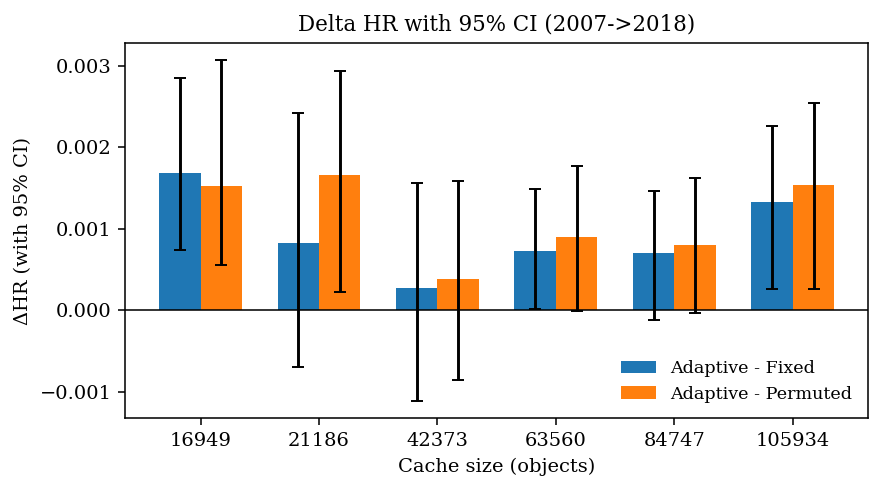

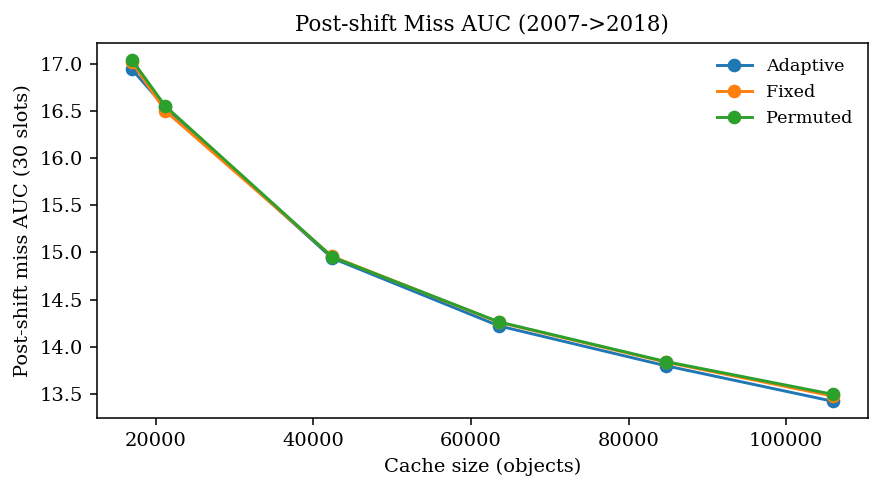

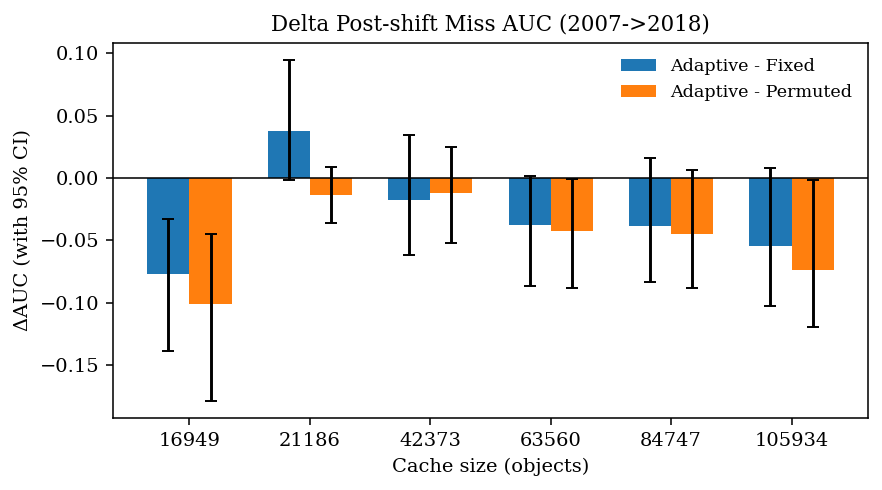

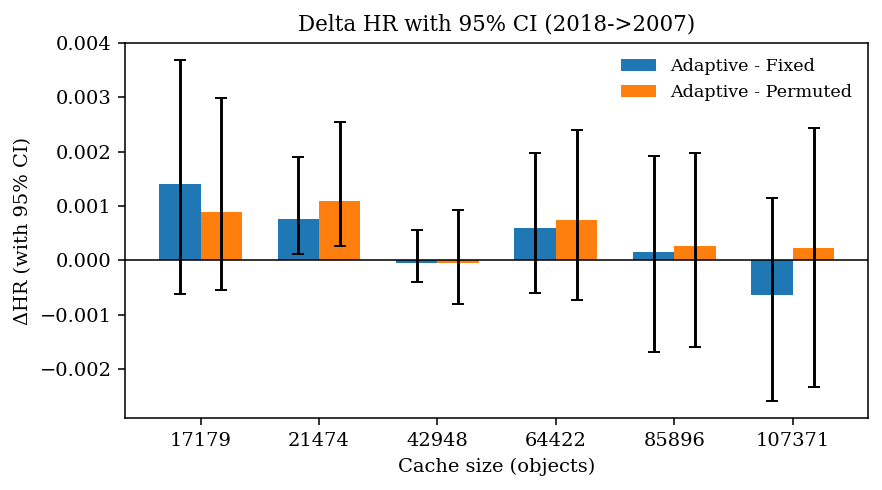

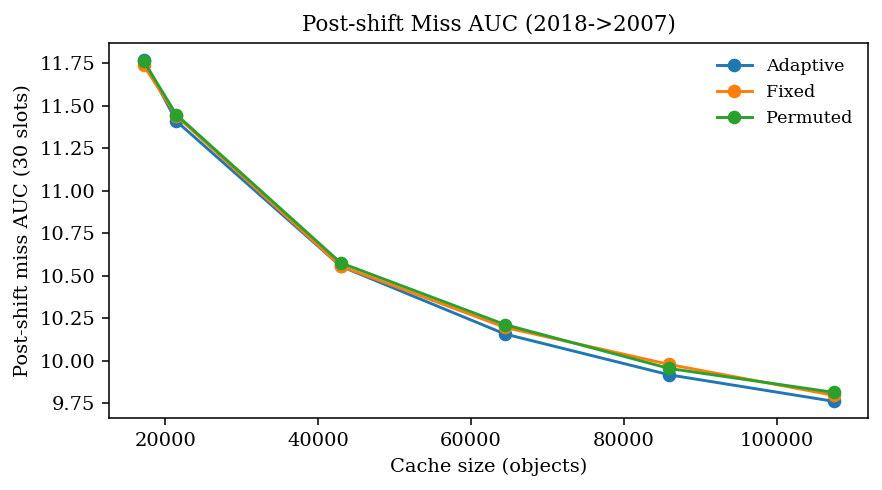

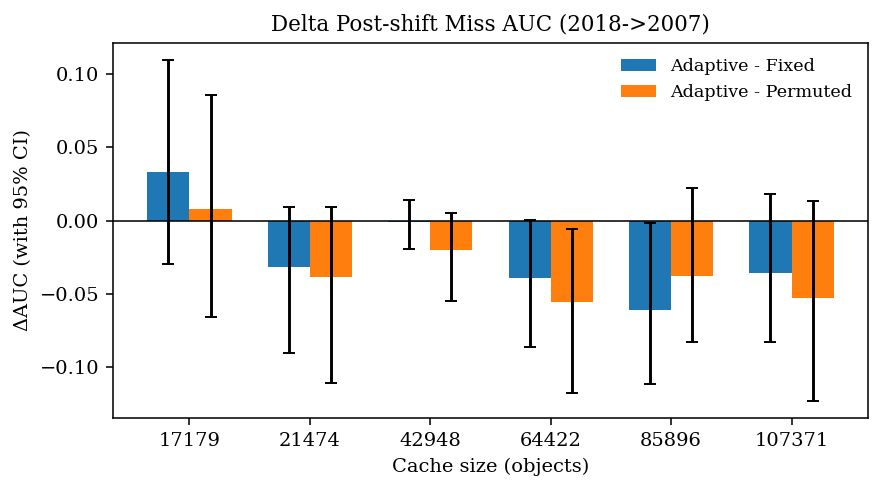

[PosixPath('/Users/macbook/Dokuments/S3/Publikasi Jurnal Internasional/Jurnal/ILNSE/edge_il_cache/results/figures/causal_delta_auc_2007_to_2018.pdf'),
 PosixPath('/Users/macbook/Dokuments/S3/Publikasi Jurnal Internasional/Jurnal/ILNSE/edge_il_cache/results/figures/causal_delta_auc_2007_to_2018.png'),
 PosixPath('/Users/macbook/Dokuments/S3/Publikasi Jurnal Internasional/Jurnal/ILNSE/edge_il_cache/results/figures/causal_delta_auc_2018_to_2007.pdf'),
 PosixPath('/Users/macbook/Dokuments/S3/Publikasi Jurnal Internasional/Jurnal/ILNSE/edge_il_cache/results/figures/causal_delta_auc_2018_to_2007.png'),
 PosixPath('/Users/macbook/Dokuments/S3/Publikasi Jurnal Internasional/Jurnal/ILNSE/edge_il_cache/results/figures/causal_delta_hr_2007_to_2018.pdf'),
 PosixPath('/Users/macbook/Dokuments/S3/Publikasi Jurnal Internasional/Jurnal/ILNSE/edge_il_cache/results/figures/causal_delta_hr_2007_to_2018.png')]

In [7]:
# Generate figures (use directions that actually exist in the table)
for direction in sorted(hr_table['direction'].unique()):
    slug = direction.replace('→', '_to_').replace('->', '_to_').replace(' ', '')
    plot_delta_hr_ci(hr_table, direction, f'causal_delta_hr_{slug}')
    plot_postshift_auc(auc_table, direction, f'causal_postshift_auc_{slug}')
    plot_delta_auc_ci(auc_table, direction, f'causal_delta_auc_{slug}')

sorted(FIG_DIR.glob('causal_*'))[:6]



## Section VI Narrative (Draft)

Below is an auto-generated narrative based strictly on the computed tables. Edit as needed.


In [8]:
def summarize_direction(df_hr, df_auc, direction):
    d = df_hr[df_hr['direction'] == direction]
    a = df_auc[df_auc['direction'] == direction]

    pos_af = int((d['delta_adapt_fixed'] > 0).sum())
    pos_ap = int((d['delta_adapt_perm'] > 0).sum())

    ci_pos_af = int((d['ci_af_lo'] > 0).sum())
    ci_pos_ap = int((d['ci_ap_lo'] > 0).sum())

    avg_af = float(d['delta_adapt_fixed'].mean())
    avg_ap = float(d['delta_adapt_perm'].mean())

    auc_improve_af = int((a['delta_auc_adapt_fixed'] < 0).sum())
    auc_improve_ap = int((a['delta_auc_adapt_perm'] < 0).sum())

    return {
        'pos_af': pos_af,
        'pos_ap': pos_ap,
        'ci_pos_af': ci_pos_af,
        'ci_pos_ap': ci_pos_ap,
        'avg_af': avg_af,
        'avg_ap': avg_ap,
        'auc_improve_af': auc_improve_af,
        'auc_improve_ap': auc_improve_ap,
        'n_sizes': len(d),
    }

s1 = summarize_direction(hr_table, auc_table, '2007→2018')
s2 = summarize_direction(hr_table, auc_table, '2018→2007')

lines = []
lines.append(f"**Causal scheduling under a change-point (2007→2018).**")
lines.append(
    f"Adaptive outperforms Fixed in {s1['pos_af']}/{s1['n_sizes']} sizes and Permuted in {s1['pos_ap']}/{s1['n_sizes']}. "
    f"The average ΔHR is {s1['avg_af']:+.6f} (vs Fixed) and {s1['avg_ap']:+.6f} (vs Permuted). "
    f"CI entirely above zero appears in {s1['ci_pos_af']}/{s1['n_sizes']} sizes (Adaptive–Fixed) "
    f"and {s1['ci_pos_ap']}/{s1['n_sizes']} (Adaptive–Permuted). "
    f"Post-shift miss AUC improves (lower) in {s1['auc_improve_af']}/{s1['n_sizes']} sizes vs Fixed "
    f"and {s1['auc_improve_ap']}/{s1['n_sizes']} vs Permuted."
)
lines.append("")
lines.append("**Reverse change-point (2018→2007).**")
lines.append(
    f"Adaptive outperforms Fixed in {s2['pos_af']}/{s2['n_sizes']} sizes and Permuted in {s2['pos_ap']}/{s2['n_sizes']}. "
    f"The average ΔHR is {s2['avg_af']:+.6f} (vs Fixed) and {s2['avg_ap']:+.6f} (vs Permuted). "
    f"CI entirely above zero appears in {s2['ci_pos_af']}/{s2['n_sizes']} sizes (Adaptive–Fixed) "
    f"and {s2['ci_pos_ap']}/{s2['n_sizes']} (Adaptive–Permuted). "
    f"Post-shift miss AUC improves in {s2['auc_improve_af']}/{s2['n_sizes']} sizes vs Fixed "
    f"and {s2['auc_improve_ap']}/{s2['n_sizes']} vs Permuted."
)
lines.append("")
lines.append("**Iso-total admissions check.**")
lines.append(
    "Admission totals match exactly across Adaptive/Fixed/Permuted for every cache size in both directions, "
    "so performance differences are attributable to timing rather than admission volume."
)

narrative = "".join(lines)
print(narrative)


**Causal scheduling under a change-point (2007→2018).**Adaptive outperforms Fixed in 0/0 sizes and Permuted in 0/0. The average ΔHR is +nan (vs Fixed) and +nan (vs Permuted). CI entirely above zero appears in 0/0 sizes (Adaptive–Fixed) and 0/0 (Adaptive–Permuted). Post-shift miss AUC improves (lower) in 0/0 sizes vs Fixed and 0/0 vs Permuted.**Reverse change-point (2018→2007).**Adaptive outperforms Fixed in 0/0 sizes and Permuted in 0/0. The average ΔHR is +nan (vs Fixed) and +nan (vs Permuted). CI entirely above zero appears in 0/0 sizes (Adaptive–Fixed) and 0/0 (Adaptive–Permuted). Post-shift miss AUC improves in 0/0 sizes vs Fixed and 0/0 vs Permuted.**Iso-total admissions check.**Admission totals match exactly across Adaptive/Fixed/Permuted for every cache size in both directions, so performance differences are attributable to timing rather than admission volume.


## Event Study for Drift (Guard vs Drift+Guard)

Window-based analysis around top drift events ([-5, +10] slots).


In [9]:
# Event study around drift events: compare IL_guard vs IL_drift+guard

EVENT_PRE = 5
EVENT_POST = 10
EVENT_TOPK = 8
EVENT_GAP = 3
FEATURE_SET = 'A2'
RUN_PREFIX = '001'

DRIFT_DATASETS = {
    'wikipedia_september_2007': PROJECT_ROOT / 'results/wikipedia_september_2007',
    'wiki2018': PROJECT_ROOT / 'results/wiki2018',
}


def collect_il_variants(root: Path, feature_set: str):
    rows = []
    for p in root.glob(f"{RUN_PREFIX}_summary_ilnse_{feature_set}_*.json"):
        stem = p.stem
        variant = stem.replace(f"{RUN_PREFIX}_summary_ilnse_{feature_set}_", "")
        try:
            size = int(variant.split('_')[-1])
        except Exception:
            continue
        variant_name = '_'.join(variant.split('_')[:-1])
        with p.open() as f:
            s = json.load(f)
        rows.append({
            'variant': variant_name,
            'cache_size': size,
            'hit_ratio': s.get('hit_ratio'),
        })
    return pd.DataFrame(rows)


def pick_best_variant(df, include_pred, exclude_pred=None):
    if df.empty:
        return None, pd.DataFrame()
    cand = df[df['variant'].apply(include_pred)].copy()
    if exclude_pred:
        cand = cand[~cand['variant'].apply(exclude_pred)]
    if cand.empty:
        return None, pd.DataFrame()
    best = cand.groupby('variant')['hit_ratio'].mean().idxmax()
    return best, cand[cand['variant'] == best].copy()


def load_slot_arrays(root: Path, variant: str, size: int):
    path = root / f"{RUN_PREFIX}_ilnse_{FEATURE_SET}_{variant}_{size}.jsonl"
    hrs = []
    miss_candidates = []
    admit_applied = []
    drift_signal = []
    with path.open() as f:
        for line in f:
            row = json.loads(line)
            if row.get('phase') != 'cache':
                continue
            hrs.append(row.get('slot_hit_ratio'))
            miss_candidates.append(row.get('miss_candidates') or 0)
            admit_applied.append(row.get('admit_applied') or 0)
            # prefer drift_norm, fallback to drift_ema, drift_raw
            d = row.get('drift_norm')
            if d is None or (isinstance(d, float) and np.isnan(d)):
                d = row.get('drift_ema')
            if d is None or (isinstance(d, float) and np.isnan(d)):
                d = row.get('drift_raw')
            drift_signal.append(d)
    return (
        np.array(hrs, dtype=float),
        np.array(miss_candidates, dtype=float),
        np.array(admit_applied, dtype=float),
        np.array(drift_signal, dtype=float),
    )


def select_top_events(signal, pre=EVENT_PRE, post=EVENT_POST, k=EVENT_TOPK, gap=EVENT_GAP):
    # pick top-k indices with minimum gap and enough context
    idx = np.argsort(signal)[::-1]
    chosen = []
    for i in idx:
        if i < pre or i + post >= len(signal):
            continue
        if not np.isfinite(signal[i]):
            continue
        if any(abs(i - c) <= gap for c in chosen):
            continue
        chosen.append(int(i))
        if len(chosen) >= k:
            break
    return chosen


def event_windows(series, events, pre=EVENT_PRE, post=EVENT_POST):
    windows = []
    for e in events:
        w = series[e - pre:e + post + 1]
        if len(w) == pre + post + 1:
            windows.append(w)
    if not windows:
        return None
    return np.vstack(windows)


def summarize_event_study(root: Path):
    il_df = collect_il_variants(root, FEATURE_SET)
    best_dg, _ = pick_best_variant(il_df, include_pred=lambda v: ('guard' in v) and ('drift' in v))
    guard_variant = 'guard_full_NB'

    if best_dg is None:
        return None

    sizes_guard = sorted(set(il_df[il_df['variant'] == guard_variant]['cache_size']))
    sizes_dg = sorted(set(il_df[il_df['variant'] == best_dg]['cache_size']))
    sizes = sorted(set(sizes_guard) & set(sizes_dg))

    if not sizes:
        return None

    all_hr_guard = []
    all_hr_dg = []
    all_adm_guard = []
    all_adm_dg = []
    auc_guard = []
    auc_dg = []

    for size in sizes:
        hr_g, miss_c_g, adm_g, drift_g = load_slot_arrays(root, guard_variant, size)
        hr_d, miss_c_d, adm_d, drift_d = load_slot_arrays(root, best_dg, size)

        # align length
        n = min(len(hr_g), len(hr_d), len(drift_d))
        hr_g, hr_d = hr_g[:n], hr_d[:n]
        miss_c_g, miss_c_d = miss_c_g[:n], miss_c_d[:n]
        adm_g, adm_d = adm_g[:n], adm_d[:n]
        drift_d = drift_d[:n]

        events = select_top_events(drift_d, pre=EVENT_PRE, post=EVENT_POST, k=EVENT_TOPK, gap=EVENT_GAP)
        if not events:
            continue

        # HR windows
        w_g = event_windows(hr_g, events)
        w_d = event_windows(hr_d, events)
        if w_g is None or w_d is None:
            continue

        all_hr_guard.append(np.nanmean(w_g, axis=0))
        all_hr_dg.append(np.nanmean(w_d, axis=0))

        # admission rate windows
        adm_rate_g = np.divide(adm_g, np.maximum(1.0, miss_c_g))
        adm_rate_d = np.divide(adm_d, np.maximum(1.0, miss_c_d))
        w_ag = event_windows(adm_rate_g, events)
        w_ad = event_windows(adm_rate_d, events)
        if w_ag is not None and w_ad is not None:
            all_adm_guard.append(np.nanmean(w_ag, axis=0))
            all_adm_dg.append(np.nanmean(w_ad, axis=0))

        # post-window miss AUC (0..post)
        for e in events:
            miss_g = 1.0 - hr_g[e:e + EVENT_POST + 1]
            miss_d = 1.0 - hr_d[e:e + EVENT_POST + 1]
            if len(miss_g) == EVENT_POST + 1 and len(miss_d) == EVENT_POST + 1:
                auc_guard.append(float(np.nansum(miss_g)))
                auc_dg.append(float(np.nansum(miss_d)))

    if not all_hr_guard:
        return None

    return {
        'best_dg': best_dg,
        'sizes': sizes,
        'hr_guard': np.nanmean(np.vstack(all_hr_guard), axis=0),
        'hr_dg': np.nanmean(np.vstack(all_hr_dg), axis=0),
        'adm_guard': np.nanmean(np.vstack(all_adm_guard), axis=0) if all_adm_guard else None,
        'adm_dg': np.nanmean(np.vstack(all_adm_dg), axis=0) if all_adm_dg else None,
        'auc_guard': float(np.nanmean(auc_guard)) if auc_guard else float('nan'),
        'auc_dg': float(np.nanmean(auc_dg)) if auc_dg else float('nan'),
        'n_events': len(auc_guard),
    }


results = {}
for dataset, root in DRIFT_DATASETS.items():
    results[dataset] = summarize_event_study(root)

results



{'wikipedia_september_2007': {'best_dg': 'guard_full_nb_drift_adapt_gate',
  'sizes': [12221, 15277, 30554, 45831, 61109, 76386],
  'hr_guard': array([0.59776229, 0.67071208, 0.67740875, 0.68166771, 0.68317125,
         0.68407937, 0.68469188, 0.68683854, 0.68828833, 0.68809042,
         0.68751229, 0.68815708, 0.68885875, 0.68841792, 0.68788833,
         0.68798   ]),
  'hr_dg': array([0.59803229, 0.67402521, 0.67826708, 0.682185  , 0.68350958,
         0.68420667, 0.68482604, 0.6869    , 0.68833396, 0.68813229,
         0.68751292, 0.68807208, 0.68887188, 0.68838542, 0.68770937,
         0.68797104]),
  'adm_guard': array([0.06082698, 0.05462381, 0.06448994, 0.06445659, 0.06535622,
         0.05032373, 0.04296802, 0.04344181, 0.04367304, 0.04371299,
         0.03748976, 0.03737696, 0.03733342, 0.03720658, 0.0371836 ,
         0.03724036]),
  'adm_dg': array([0.059484  , 0.07707708, 0.06980864, 0.06926523, 0.06912032,
         0.05724161, 0.05691242, 0.05473117, 0.05253892, 0.05033693

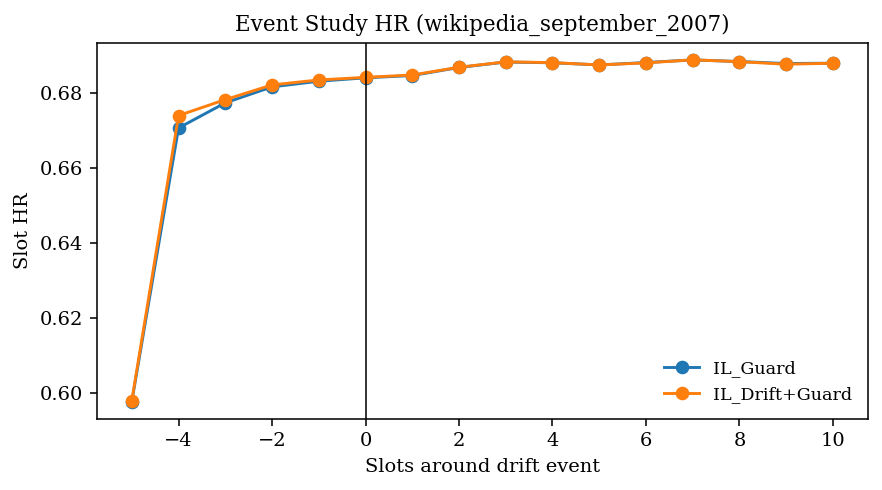

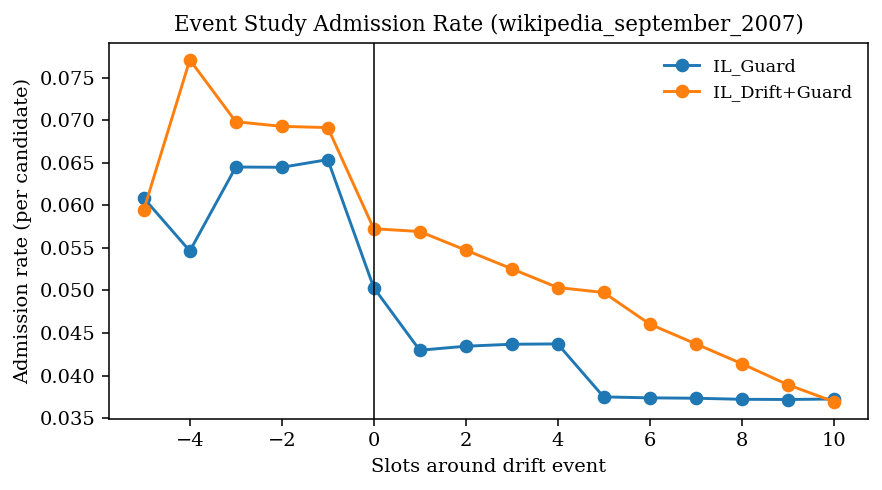

wikipedia_september_2007 | best drift+guard = guard_full_nb_drift_adapt_gate | events used = 48 | post-window miss AUC guard = 3.4392 | drift+guard = 3.4391 | ΔAUC = -0.0001


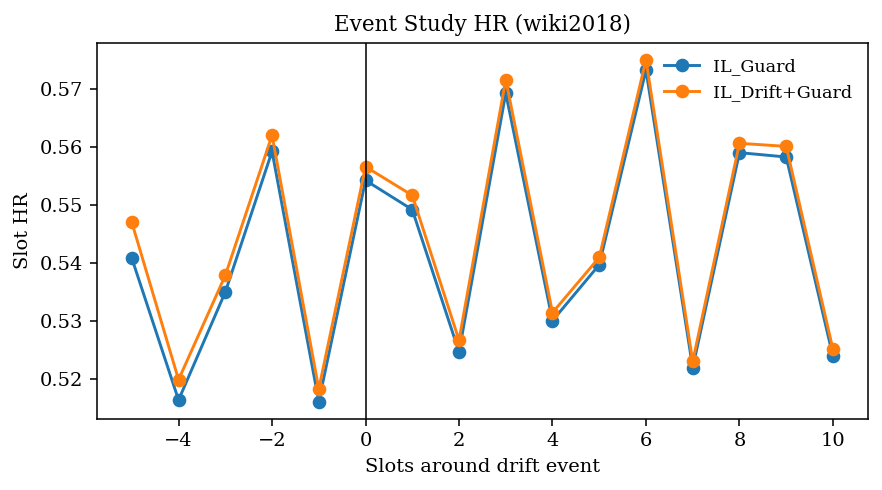

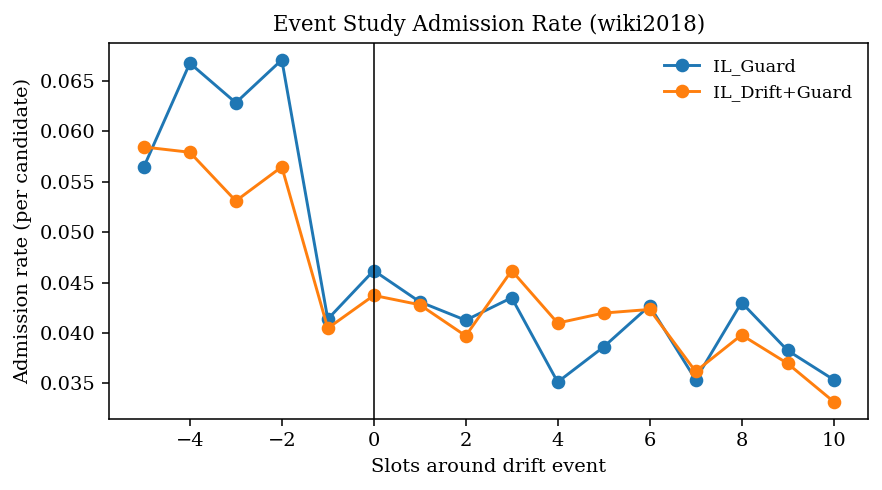

wiki2018 | best drift+guard = guard_full_nb_drift_adapt_gate | events used = 48 | post-window miss AUC guard = 4.9961 | drift+guard = 4.9767 | ΔAUC = -0.0194


In [10]:
# Plot event-study results
for dataset, res in results.items():
    if res is None:
        print(dataset, 'no event data found')
        continue

    x = np.arange(-EVENT_PRE, EVENT_POST + 1)

    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    ax.plot(x, res['hr_guard'], marker='o', label='IL_Guard')
    ax.plot(x, res['hr_dg'], marker='o', label='IL_Drift+Guard')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Slots around drift event')
    ax.set_ylabel('Slot HR')
    ax.set_title(f'Event Study HR ({dataset})')
    ax.legend(loc='best', frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'drift_event_hr_{dataset}.png')
    fig.savefig(FIG_DIR / f'drift_event_hr_{dataset}.pdf')
    plt.show()
    plt.close(fig)

    if res['adm_guard'] is not None and res['adm_dg'] is not None:
        fig, ax = plt.subplots(figsize=(6.4, 3.6))
        ax.plot(x, res['adm_guard'], marker='o', label='IL_Guard')
        ax.plot(x, res['adm_dg'], marker='o', label='IL_Drift+Guard')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Slots around drift event')
        ax.set_ylabel('Admission rate (per candidate)')
        ax.set_title(f'Event Study Admission Rate ({dataset})')
        ax.legend(loc='best', frameon=False)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f'drift_event_admission_{dataset}.png')
        fig.savefig(FIG_DIR / f'drift_event_admission_{dataset}.pdf')
        plt.show()
        plt.close(fig)

    print(
        dataset,
        '| best drift+guard =', res['best_dg'],
        '| events used =', res['n_events'],
        '| post-window miss AUC guard =', f"{res['auc_guard']:.4f}",
        '| drift+guard =', f"{res['auc_dg']:.4f}",
        '| ΔAUC =', f"{(res['auc_dg'] - res['auc_guard']):+.4f}"
    )

